In [ ]:
!pip install opencv-python-headless

In [ ]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

In [ ]:
name = input("Enter your name: ")

Enter your name: Arish


In [ ]:
def record_video(filename, duration=1500):
    js_code = f"""
    async function recordVideo() {{
        const div = document.createElement('div');

        const startBtn = document.createElement('button');
        startBtn.textContent = 'Start Recording';
        div.appendChild(startBtn);

        const video = document.createElement('video');
        video.style.display = 'block';
        div.appendChild(video);

        document.body.appendChild(div);

        const stream = await navigator.mediaDevices.getUserMedia({{video: true, audio: true}});
        video.srcObject = stream;
        await video.play();

        await new Promise(resolve => startBtn.onclick = resolve);

        const recorder = new MediaRecorder(stream);
        let chunks = [];

        recorder.ondataavailable = e => chunks.push(e.data);
        recorder.start();

        await new Promise(resolve => setTimeout(resolve, {duration}));

        recorder.stop();

        return new Promise(resolve => {{
            recorder.onstop = () => {{
                const blob = new Blob(chunks, {{ type: 'video/webm' }});
                const reader = new FileReader();
                reader.readAsDataURL(blob);
                reader.onloadend = () => {{
                    stream.getTracks().forEach(track => track.stop());
                    div.remove();
                    resolve(reader.result);
                }};
            }};
        }});
    }}
    """
    display(Javascript(js_code))
    data = eval_js("recordVideo()")

    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# Record
video_file = record_video(f"{name}.webm", duration=15000)
print("Recorded:", video_file)

<IPython.core.display.Javascript object>

Recorded: Test4.webm


In [ ]:
!ffmpeg -i {/co/content/Test1.webmTest1.webm}.webm -vf fps=30 {Test1}.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
video_path = f"Arish.mp4"
output_folder = name

os.makedirs(output_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)

frame_count = 0

while True:
    success, frame = cap.read()
    if not success:
        break

    file_path = os.path.join(output_folder, f"frame_{frame_count}.jpg")
    cv2.imwrite(file_path, frame)

    frame_count += 1

cap.release()

print(f"Total frames stored in '{name}/':", frame_count)

Total frames stored in 'Arish/': 449


In [ ]:
import shutil

shutil.make_archive(name, 'zip', name)

'/content/Test4.zip'

In [ ]:
import shutil

shutil.rmtree("veenus")

In [ ]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=5c0c4f5e3c6597b052837205fa32539f18b825e1b6c8cceabe10e22ba61418d9
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [ ]:
import face_recognition
import os

embeddings = []
names = []

for person in os.listdir("dataset_cv"):
    for img_name in os.listdir(f"dataset_cv/{person}"):
        path = f"dataset_cv/{person}/{img_name}"

        image = face_recognition.load_image_file(path)
        encodings = face_recognition.face_encodings(image)

        if len(encodings) > 0:
            embeddings.append(encodings[0])   # 128D vector
            names.append(person)

In [ ]:
import cv2
import os

faces = []
labels = []
label_map = {}
label_id = 0

for person in os.listdir("dataset_cv"):
    label_map[label_id] = person

    for img_name in os.listdir(f"dataset_cv/{person}"):
        img = cv2.imread(f"dataset_cv/{person}/{img_name}", 0)
        faces.append(img)
        labels.append(label_id)

    label_id += 1

model = cv2.face.LBPHFaceRecognizer_create()
model.train(faces, np.array(labels))

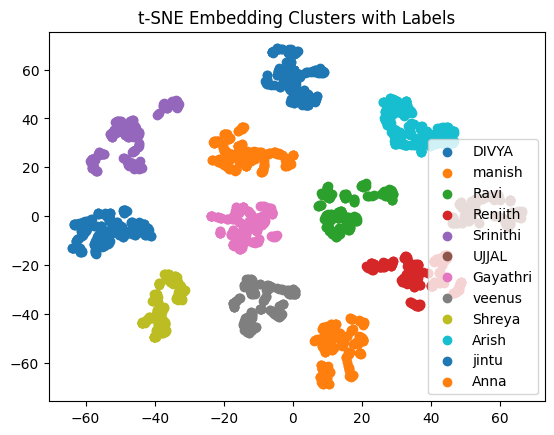

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

X = np.array(data["embeddings"])
labels = np.array(data["labels"])

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

# Plot
plt.figure()

for label in set(labels):
    idx = labels == label
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=label)

plt.legend()
plt.title("t-SNE Embedding Clusters with Labels")
plt.show()